<a href="https://colab.research.google.com/github/Innovatewithapple/Pipelines-CrossValidation-Regularisation/blob/main/RegressionPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,GridSearchCV
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [4]:
df = pd.read_csv('/content/advertising.csv')
df.sample(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
152,197.6,23.3,14.2,16.6
192,17.2,4.1,31.6,5.9
6,57.5,32.8,23.5,11.8
175,276.9,48.9,41.8,27.0


In [5]:
df.skew()

,0
TV,-0.069853
Radio,0.094175
Newspaper,0.894720
Sales,-0.073739


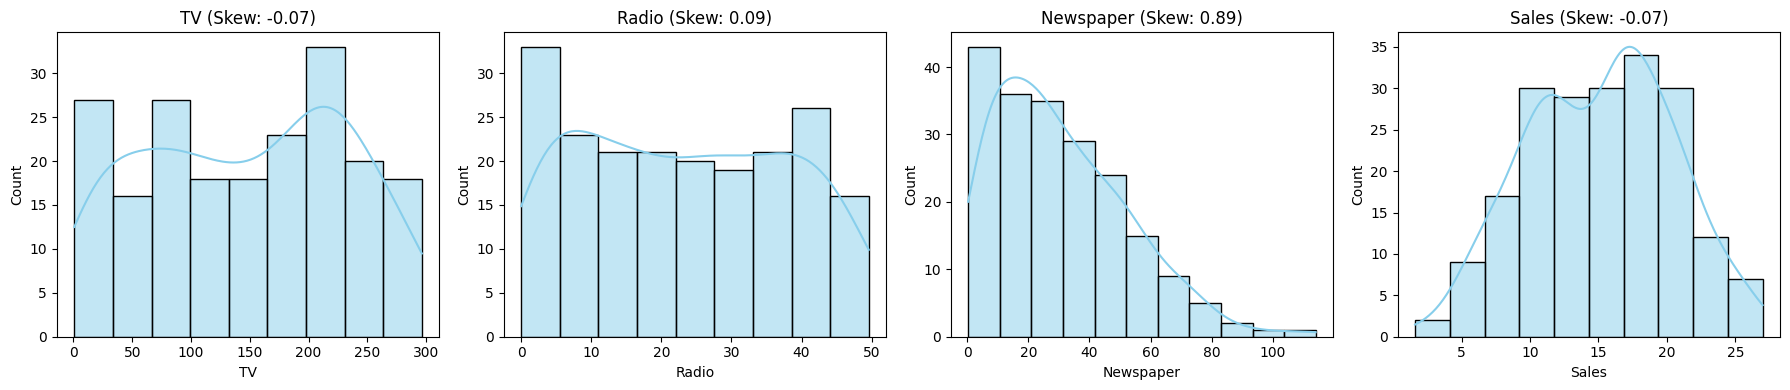

In [14]:
#kde=True: This is the most important part for checking skewness! It stands for Kernel Density Estimate. It draws that smooth blue line over the bars. It helps your eyes see the "shape" of the data much better than just looking at the bars.
# Create a figure with 1 row and 4 columns
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# List of your columns
columns = ['TV', 'Radio', 'Newspaper', 'Sales']

# Loop through and plot each one
for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} (Skew: {round(df[col].skew(), 2)})')

plt.tight_layout()
plt.show()

In [16]:
# 1. Initialize the transformer
pt = PowerTransformer(method='yeo-johnson')

# 2. Fit and transform your features (TV, Radio, Newspaper)
# This finds the best transformation for each column automatically
df[['TV', 'Radio', 'Newspaper']] = pt.fit_transform(df[['TV', 'Radio', 'Newspaper']])

# 3. Check the skew again - they should all be very close to 0 now!
print(df[['TV', 'Radio', 'Newspaper']].skew())

TV          -0.315199
Radio       -0.242968
Newspaper   -0.077942
dtype: float64


In [19]:
x = df.drop(columns='Sales')
y = df['Sales']

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [21]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [22]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [23]:
cross_score_linear = cross_validate(pipeline,x_train,y_train,cv=5,scoring=[
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "r2"
    ])
cross_score_linear

{'fit_time': array([0.01173329, 0.00699472, 0.00719118, 0.00662732, 0.00671387]),
 'score_time': array([0.01274753, 0.01099992, 0.00638008, 0.00605202, 0.00597143]),
 'test_neg_mean_absolute_error': array([-1.33711777, -1.21161831, -1.52152053, -1.1729899 , -1.28763484]),
 'test_neg_mean_squared_error': array([-2.65719857, -2.47100767, -3.12804379, -2.29328404, -3.14033986]),
 'test_r2': array([0.88723424, 0.89312127, 0.88366482, 0.91904503, 0.88209047])}

In [24]:
# Ridge
pipelone_ridge = Pipeline([
    ('scaler',StandardScaler()),
    ('model',Ridge())
])

In [25]:
pipelone_ridge.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [26]:
cross_score_ridge = cross_validate(pipelone_ridge,x_train,y_train,cv=5,scoring=[
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "r2"
    ])
cross_score_ridge

{'fit_time': array([0.00644612, 0.00673103, 0.0052166 , 0.01111078, 0.00543118]),
 'score_time': array([0.00580049, 0.00453115, 0.00426102, 0.0045476 , 0.00442624]),
 'test_neg_mean_absolute_error': array([-1.33598175, -1.20985698, -1.52636533, -1.16789358, -1.30058354]),
 'test_neg_mean_squared_error': array([-2.64945884, -2.45271095, -3.12702978, -2.26983355, -3.19091834]),
 'test_r2': array([0.8875627 , 0.89391266, 0.88370253, 0.91987285, 0.88019141])}

In [27]:
# Lasso
pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

In [28]:
pipeline_lasso.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Lasso())])

In [29]:
cross_score_lasso = cross_validate(pipeline_lasso,x_train,y_train,cv=5,scoring=[
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "r2"
    ])
cross_score_lasso

{'fit_time': array([0.00593376, 0.00522804, 0.00928497, 0.00445199, 0.00426197]),
 'score_time': array([0.00444913, 0.00444865, 0.00584149, 0.00365853, 0.00365925]),
 'test_neg_mean_absolute_error': array([-1.56385006, -1.49082256, -1.98324213, -1.3708934 , -1.85637748]),
 'test_neg_mean_squared_error': array([-3.72777184, -3.51960508, -5.70489007, -4.22751742, -5.68094378]),
 'test_r2': array([0.84180143, 0.84776618, 0.78782924, 0.85076486, 0.78669907])}

🧠 🔥 1. What is solver?

👉 Solver = how the model finds the best coefficients (weights)

🧠 🔥 1. What is solver?

👉 Solver = how the model finds the best coefficients (weights)

💡 Think like this:

You want to minimize error:

find best weights → minimize loss

👉 Solver = the method used to reach that solution

🚀 Types of solvers (Ridge / Linear)
🟢 "auto"

👉 Let sklearn decide best solver

✔ safest option
✔ use this 90% of time

🟢 "svd" (Singular Value Decomposition)

👉 Mathematical direct solution

✔ very stable
❌ slow for large data

👉 Use when:

small dataset
want precision
🟢 "cholesky"

👉 Faster matrix math

✔ fast
❌ less stable if data messy

🟢 "sag" / "saga" (IMPORTANT 🔥)

👉 Gradient descent style (iterative)

✔ good for large datasets
✔ supports regularization

👉 "saga":

works with L1 (Lasso) + L2
most flexible
🟢 "lsqr"

👉 Iterative solver for large sparse data

💥 SIMPLE MEMORY
Solver	Meaning
auto	sklearn decides
svd	accurate but slow
cholesky	fast math
saga	modern + scalable 🔥

In [30]:
param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["auto", "svd", "cholesky"]
}

In [32]:
better = GridSearchCV(pipelone_ridge,param_grid_ridge,cv=5,scoring='neg_mean_squared_error')
better.fit(x_train, y_train)

print(better.best_params_)

{'model__alpha': 0.1, 'model__solver': 'svd'}


In [ ]:
param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__max_iter": [1000, 5000]
}

In [ ]:
better = GridSearchCV(cross_score_lasso,param_grid_lasso,cv=5,scoring='neg_mean_squared_error')